<a href="https://colab.research.google.com/github/MehelaMariyo/NLP_Real_Vs_Fake_News_Prediction.ipynb/blob/main/NLP_News_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [2]:
# import the dataset
data = pd.read_csv("/content/news.csv")
data.head()

,text,label
0,Gere faults Trump for blurring meaning of 'ref...,1
1,German parties start to find common ground in ...,1
2,Senate Democratic leader says Attorney General...,1
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",1
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,0


In [3]:
data.shape

(45757, 2)

In [4]:
data.isnull().sum()

,0
text,0
label,0


In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.nunique()

,0
text,45757
label,2


In [7]:
data.label.value_counts()

,count
label,
1,22900
0,22857


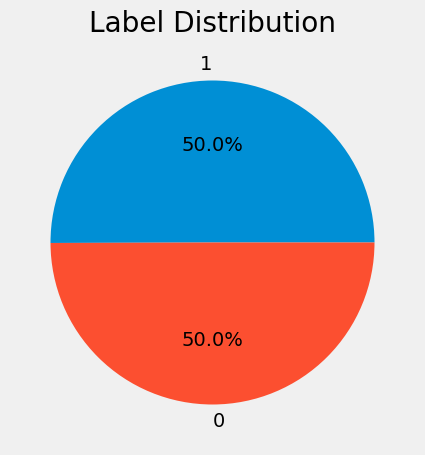

In [8]:
plt.figure(figsize=(10,5))
plt.pie(data.label.value_counts(),labels=data.label.value_counts().index,autopct='%1.1f%%')
plt.title('Label Distribution')
plt.show()

Since the targent variable has same amount of values for both classes, this is a class balnce problem.




In [9]:
# Spliting the dataset into features and target

X = data.text
y = data.label

In [14]:
tfdr = TfidfVectorizer()
X = tfdr.fit_transform(X)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((36605, 162145), (9152, 162145), (36605,), (9152,))

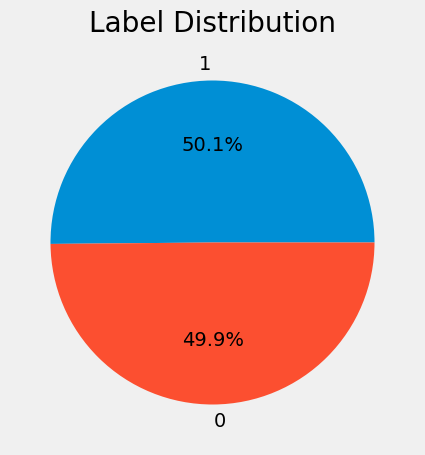

In [30]:
plt.figure(figsize=(10,5))
plt.pie(y_train.value_counts(),labels=y_train.value_counts().index,autopct='%1.1f%%')
plt.title('Label Distribution')
plt.show()

In [17]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

In [23]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluates a given model by printing a classification report, plotting a confusion matrix, and plotting an ROC curve.

    Args:
        model: The trained model object.
        X_test: Test features.
        y_test: True labels for the test set.
        model_name (str): Name of the model for plot titles and reports.
    """
    print(f"\n--- Evaluation for {model_name} ---")

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Classification Report
    print(f"\nClassification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {model_name}')
    plt.legend(loc='lower right')
    plt.show()


--- Evaluation for Logistic Regression ---

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4606
           1       0.98      0.97      0.97      4546

    accuracy                           0.97      9152
   macro avg       0.97      0.97      0.97      9152
weighted avg       0.97      0.97      0.97      9152



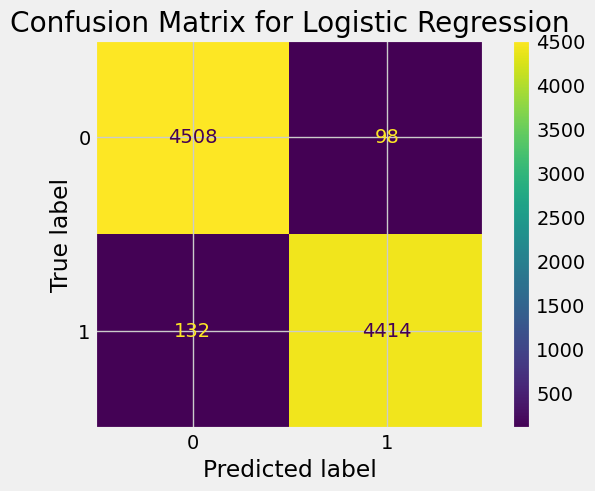

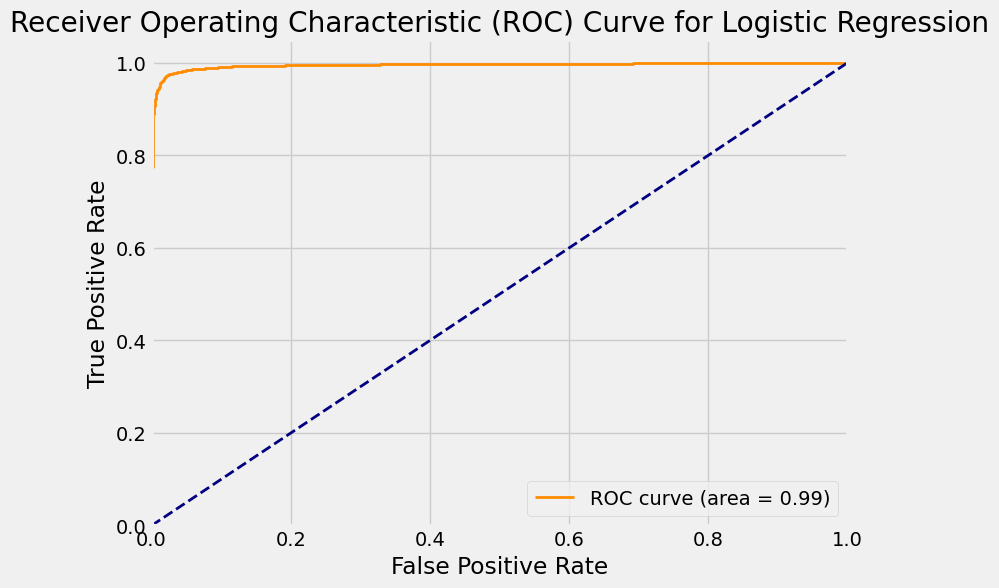

In [24]:
model_lr_evaluation = evaluate_model(model_lr, X_test, y_test, model_name="Logistic Regression")
model_lr_evaluation

In [28]:
from sklearn.naive_bayes import MultinomialNB

model_mnb = MultinomialNB()
model_mnb.fit(X_train, y_train)

MultinomialNB()


--- Evaluation for Multinomial Naive Bayes ---

Classification Report for Multinomial Naive Bayes:

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      4606
           1       0.93      0.92      0.92      4546

    accuracy                           0.92      9152
   macro avg       0.92      0.92      0.92      9152
weighted avg       0.92      0.92      0.92      9152



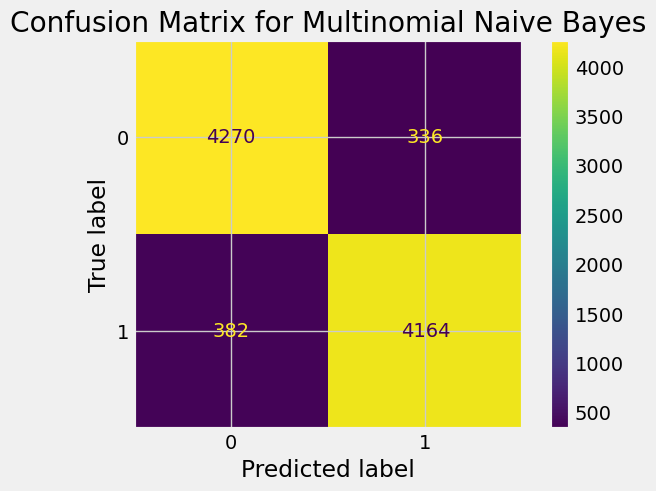

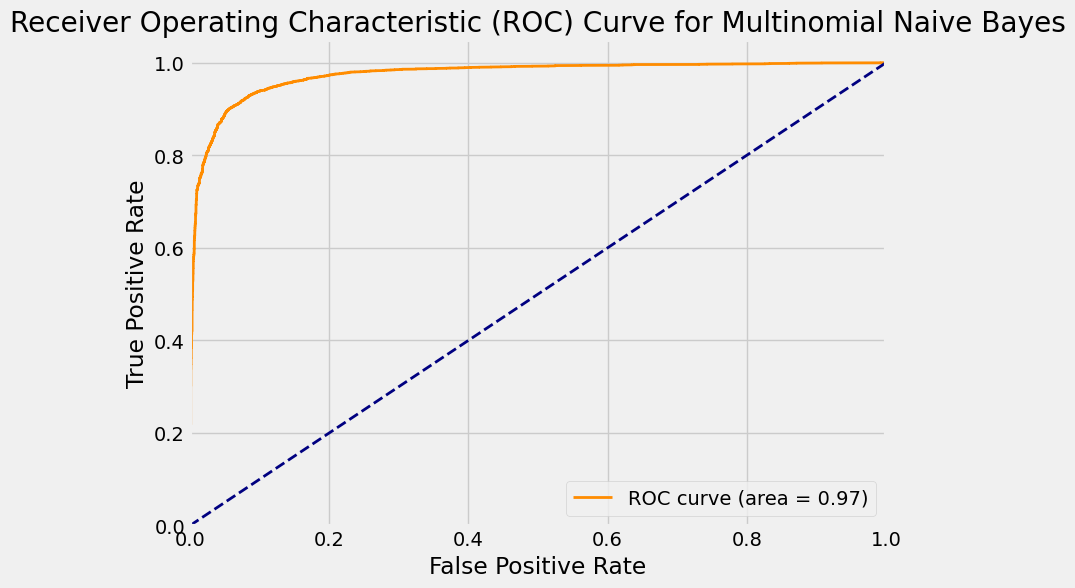

In [29]:
evaluate_model(model_mnb, X_test, y_test, model_name="Multinomial Naive Bayes")

In [31]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)


--- Evaluation for Decision Tree ---

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4606
           1       0.98      0.98      0.98      4546

    accuracy                           0.98      9152
   macro avg       0.98      0.98      0.98      9152
weighted avg       0.98      0.98      0.98      9152



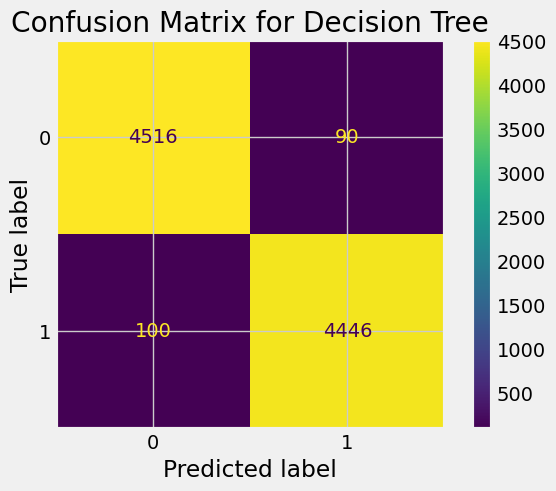

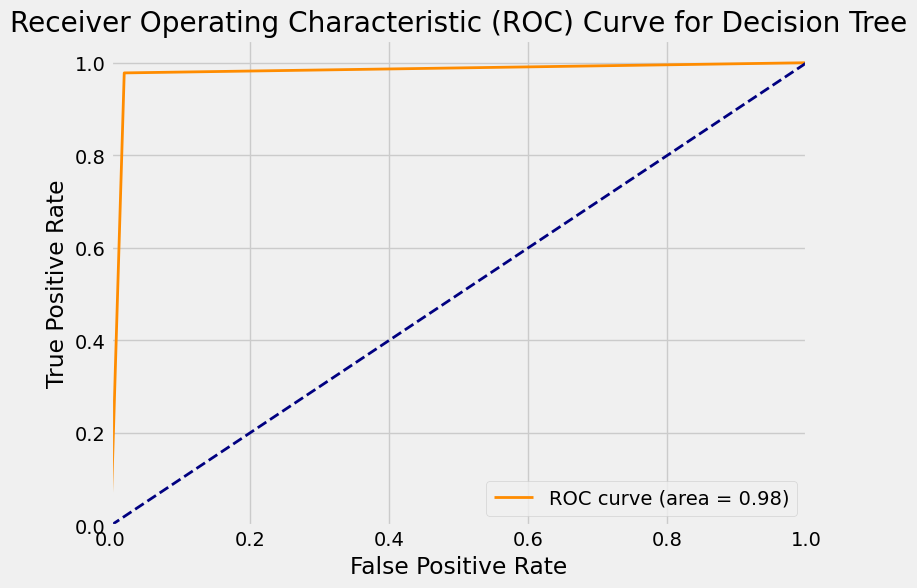

In [32]:
evaluate_model(model_dt, X_test, y_test, model_name="Decision Tree")

In [33]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)


--- Evaluation for Random Forest ---

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4606
           1       0.97      0.95      0.96      4546

    accuracy                           0.96      9152
   macro avg       0.96      0.96      0.96      9152
weighted avg       0.96      0.96      0.96      9152



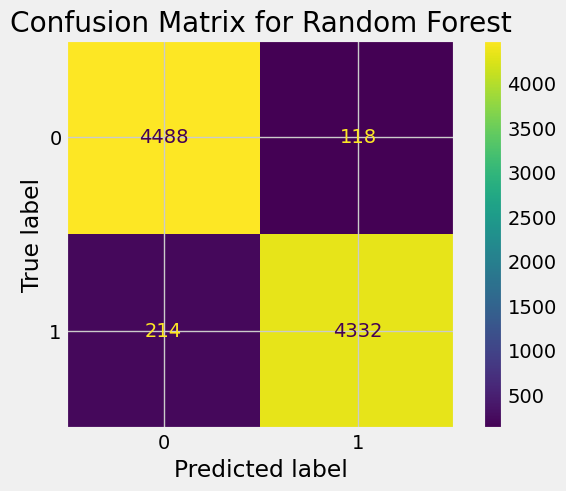

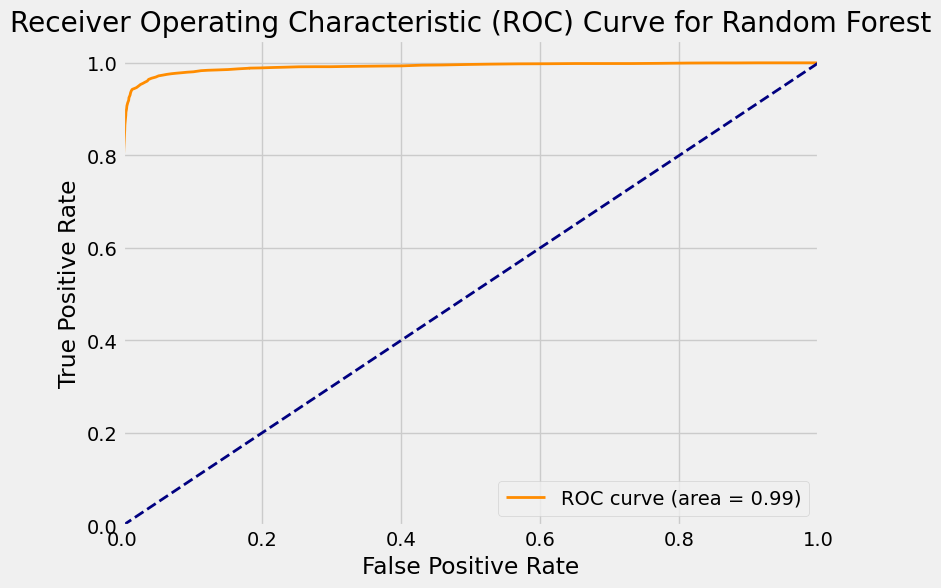

In [34]:
evaluate_model(model_rf, X_test, y_test, model_name="Random Forest")

In [35]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42)
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


--- Evaluation for XGBoost ---

Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4606
           1       0.99      0.98      0.99      4546

    accuracy                           0.99      9152
   macro avg       0.99      0.99      0.99      9152
weighted avg       0.99      0.99      0.99      9152



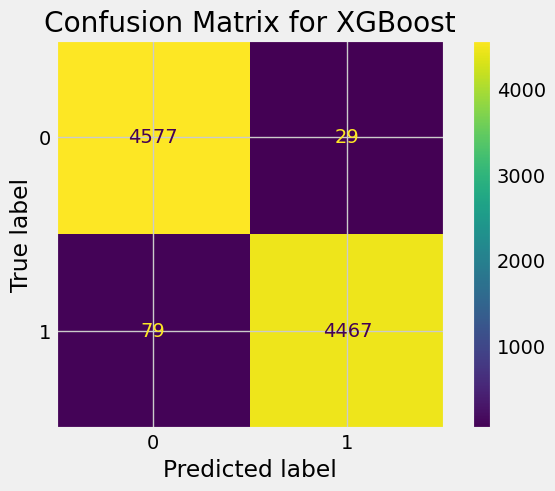

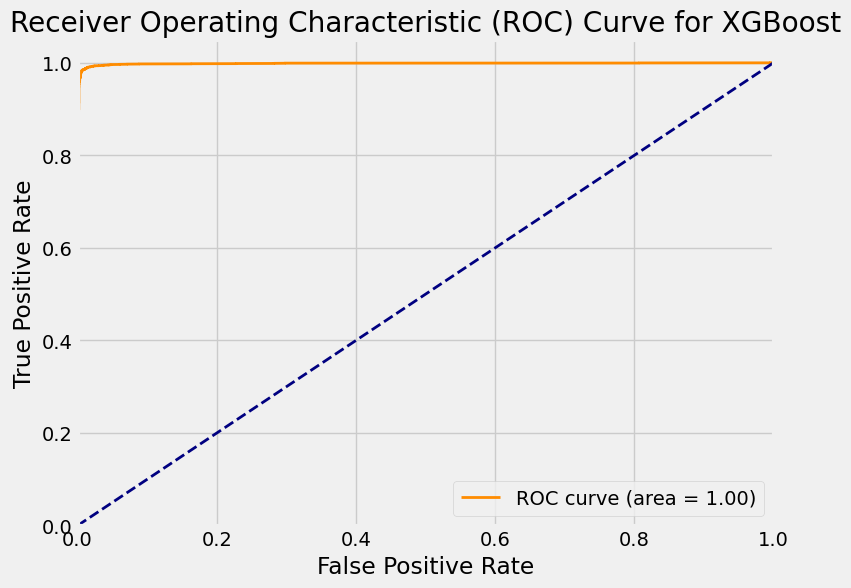

In [36]:
evaluate_model(model_xgb, X_test, y_test, model_name="XGBoost")

In [39]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [40]:
from catboost import CatBoostClassifier

model_cat = CatBoostClassifier(random_state=42, verbose=0)
model_cat.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)


--- Evaluation for CatBoost ---

Classification Report for CatBoost:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4606
           1       0.99      0.98      0.98      4546

    accuracy                           0.98      9152
   macro avg       0.98      0.98      0.98      9152
weighted avg       0.98      0.98      0.98      9152



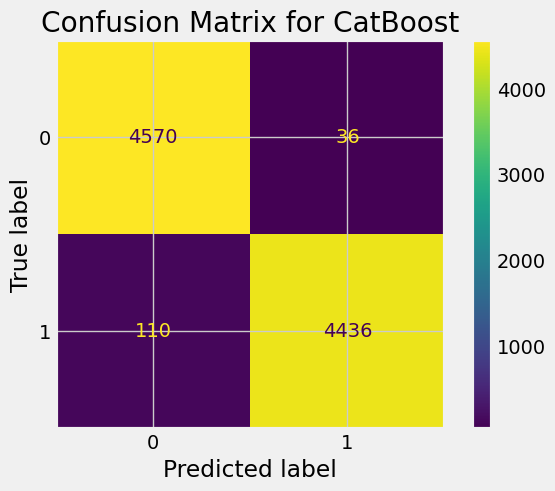

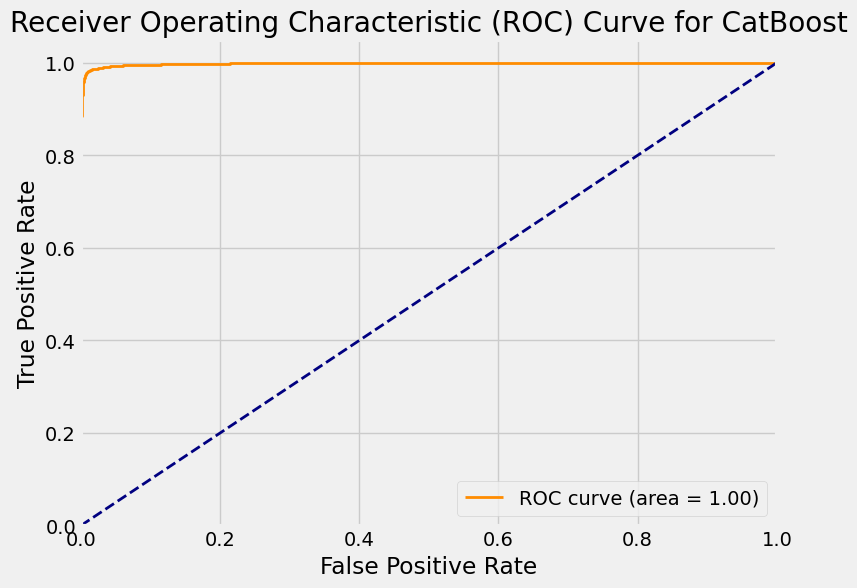

In [41]:
evaluate_model(model_cat, X_test, y_test, model_name="CatBoost")

[LightGBM] [Info] Number of positive: 18354, number of negative: 18251
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 17.631977 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1271106
[LightGBM] [Info] Number of data points in the train set: 36605, number of used features: 20350
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501407 -> initscore=0.005628
[LightGBM] [Info] Start training from score 0.005628

--- Evaluation for LightGBM ---

Classification Report for LightGBM:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4606
           1       0.99      0.98      0.99      4546

    accuracy                           0.99      9152
   macro avg       0.99      0.99      0.99      9152
weighted avg       0.99      0.99      0.99      9152



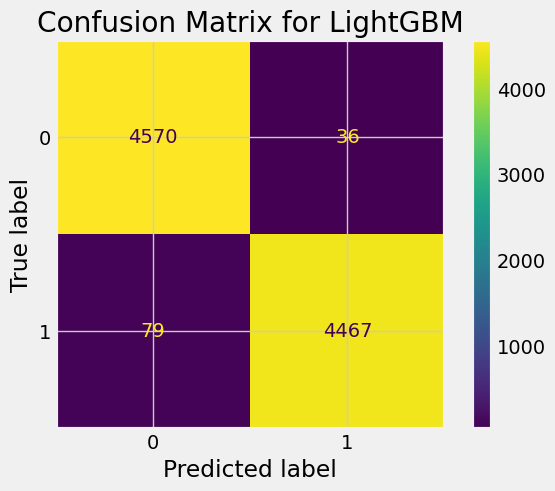

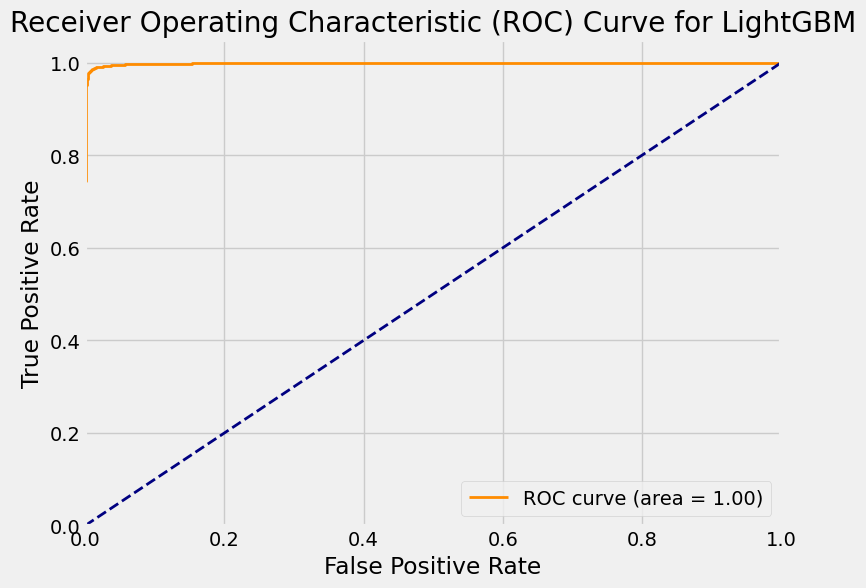

In [42]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(random_state=42)
model_lgbm.fit(X_train, y_train)

evaluate_model(model_lgbm, X_test, y_test, model_name="LightGBM")

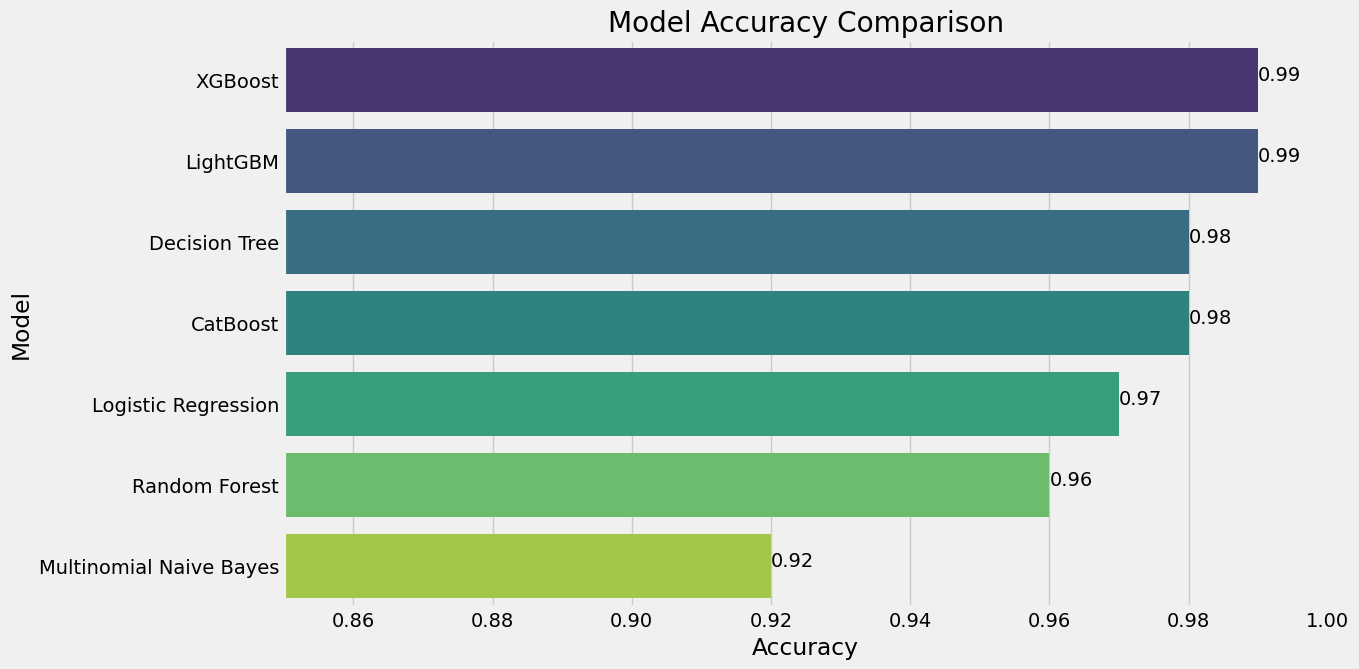

In [51]:
model_names = [
    "Logistic Regression",
    "Multinomial Naive Bayes",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "CatBoost",
    "LightGBM"
]

accuracies = [
    0.97,
    0.92,
    0.98,
    0.96,
    0.99,
    0.98,
    0.99
]

accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Model Accuracy Comparison')
plt.xlim(0.85, 1.0)

for index, row in accuracy_df.iterrows():
    plt.text(row.Accuracy, index, f'{row.Accuracy:.2f}')

plt.show()

In [54]:
def predict_news_category(news_text):
    """Predicts if a given news text is real or fake using the trained XGBoost model and returns probabilities."""
    # Transform the input text using the pre-fitted TF-IDF vectorizer
    text_vectorized = tfdr.transform([news_text])

    # Make a prediction using the XGBoost model
    prediction = model_xgb.predict(text_vectorized)
    probabilities = model_xgb.predict_proba(text_vectorized)

    predicted_label = "Real News" if prediction[0] == 1 else "Fake News"
    fake_prob = probabilities[0][0]
    real_prob = probabilities[0][1]

    return predicted_label, fake_prob, real_prob

print("Enter the news article text below. Type 'done' on a new line to finish.")

user_input_lines = []
while True:
    line = input()
    if line.lower() == 'done':
        break
    user_input_lines.append(line)

user_news_article = " ".join(user_input_lines)

if user_news_article.strip():
    predicted_category, fake_prob, real_prob = predict_news_category(user_news_article)
    print(f"\nThe news article is predicted to be: {predicted_category}")
    print(f"Probability of Fake News: {fake_prob:.4f}")
    print(f"Probability of Real News: {real_prob:.4f}")
else:
    print("No news article entered. Please try again.")


Enter the news article text below. Type 'done' on a new line to finish.
In a discovery that threatens to upend modern paleontology, a joint expedition of researchers announced Tuesday that they have unearthed a fully intact, gear-driven mechanical device from deep within the Vostok Subglacial Highlands in Antarctica.
done

The news article is predicted to be: Fake News
Probability of Fake News: 0.9142
Probability of Real News: 0.0858
